In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [87]:
X_xor = torch.tensor([[0.0, 0.0],     
                      [0.0, 1.0],     
                      [1.0, 0.0],     
                      [1.0, 1.0]])    

y_xor = torch.tensor([[0.0],
                      [1.0],
                      [1.0],
                      [0.0]])


In [88]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x
    
model = XORNet()

for p in model.parameters():
    print(f'학습가능한 파라메터 수: {p.numel()}')
    print(f'가중치 및 바이어스 값: {p}')
        


학습가능한 파라메터 수: 8
가중치 및 바이어스 값: Parameter containing:
tensor([[ 0.5406,  0.5869],
        [-0.1657,  0.6496],
        [-0.1549,  0.1427],
        [-0.3443,  0.4153]], requires_grad=True)
학습가능한 파라메터 수: 4
가중치 및 바이어스 값: Parameter containing:
tensor([ 0.6233, -0.5188,  0.6146,  0.1323], requires_grad=True)
학습가능한 파라메터 수: 4
가중치 및 바이어스 값: Parameter containing:
tensor([[ 0.3694,  0.0677,  0.2411, -0.0706]], requires_grad=True)
학습가능한 파라메터 수: 1
가중치 및 바이어스 값: Parameter containing:
tensor([0.3854], requires_grad=True)


In [89]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

In [90]:
epochs = 1000
loss_history = []
for epoch in range(epochs):
    # 기울기 초기화
    optimizer.zero_grad()
    # forward : 순전파(예측)
    predict = model(X_xor)
    # loss 계산
    loss = criterion(predict, y_xor)
    # backward : 역전파 (체이닝룰) - 각 계산 스텝별 기울기 계산
    loss.backward()
    # update : 이전 기울기 - backward에서 구한 기울기
    optimizer.step()
    # loss_history에 loss 저장
    loss_history.append(loss.item())
    if (epoch+1) % 200 ==0:
        print(f'epoch: {epoch+1, epochs} loss: {loss.item()}')


epoch: (200, 1000) loss: 0.17800430953502655
epoch: (400, 1000) loss: 0.025707358494400978
epoch: (600, 1000) loss: 0.009478487074375153
epoch: (800, 1000) loss: 0.004902699496597052
epoch: (1000, 1000) loss: 0.002985338680446148


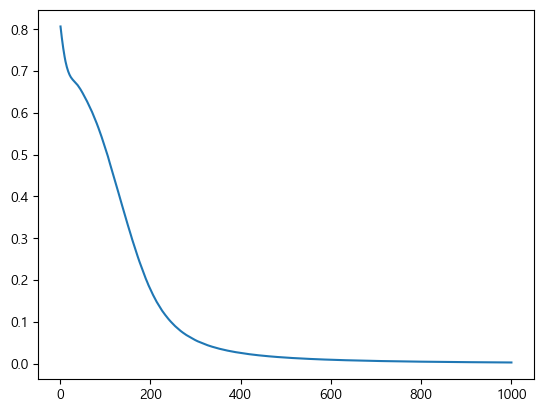

In [91]:
plt.plot(range(1, epochs+1),loss_history)
plt.show()

In [92]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

iris = load_iris()
X = iris.data
y = iris.target

x_train_full, x_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(x_train, y_train)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

for data in train_loader:
    print(data)
    break


[tensor([[ 1.2571, -0.0161,  0.9228,  1.1734],
        [ 0.0393, -0.2372,  0.2448,  0.3866],
        [-1.5438,  0.2049, -1.3372, -1.3182],
        [-0.9349,  1.5313, -1.0547, -1.0559],
        [-0.9349,  0.6471, -1.2807, -1.3182],
        [-0.8131,  0.8681, -1.2807, -1.3182],
        [ 1.6225,  0.2049,  1.2618,  0.7800],
        [-0.9349,  0.8681, -1.3372, -1.1870],
        [ 0.5265, -1.3425,  0.6968,  0.9111],
        [-0.4478,  2.4155, -1.3372, -1.3182],
        [ 0.6482,  0.2049,  0.4143,  0.3866],
        [-1.3003,  0.6471, -1.2242, -1.3182],
        [-1.0567,  0.8681, -1.3937, -1.1870],
        [-0.0825, -1.1214,  0.1318, -0.0068],
        [ 0.4047, -0.6793,  0.5838,  0.7800],
        [-0.3260, -0.9004,  0.2448,  0.1243]]), tensor([2, 1, 0, 0, 0, 0, 2, 0, 2, 0, 1, 0, 0, 1, 2, 1])]


In [93]:
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(4, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 3)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.layer3(x)
        return x  # <- 리턴 꼭 하기... 

model = IrisClassifier()

In [94]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 100
epoch_losses, epoch_val_losses = [], []
epoch_accs, val_accs = [], []

for epoch in range(epochs):
    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predict = model(batch_x)
        loss = criterion(predict, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        acc = torch.softmax(predict, axis=1)
        _, class_index = torch.max(acc, dim=1)
        acc = sum(class_index == batch_y) / len(batch_y)
        epoch_acc += acc.item()

    avg_acc = epoch_acc / len(train_loader)
    epoch_accs.append(avg_acc)
    
    avg_loss = epoch_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    with torch.no_grad():
        val_predict = model(x_val)
        val_loss = criterion(val_predict, y_val).item()
        epoch_val_losses.append(val_loss)

        # _, val_acc_index = torch.max(torch.softmax(val_predict, axis=1), dim=1)
        # val_acc = sum(val_acc_index == y_val) / len(y_val)
        # val_accs.append(val_acc)    나중에 구조 다시 확인!!

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] \
        - 평균 Loss: {avg_loss:.4f} val loss {val_loss:.4f} \
        - 평균 ACC: {avg_acc:.4f} "
        )

Epoch [ 20/100]         - 평균 Loss: 0.0331 val loss 0.2924         - 평균 ACC: 1.0000 
Epoch [ 40/100]         - 평균 Loss: 0.0136 val loss 0.5322         - 평균 ACC: 1.0000 
Epoch [ 60/100]         - 평균 Loss: 0.0068 val loss 0.6938         - 평균 ACC: 1.0000 
Epoch [ 80/100]         - 평균 Loss: 0.0045 val loss 0.8635         - 평균 ACC: 1.0000 
Epoch [100/100]         - 평균 Loss: 0.0031 val loss 0.9778         - 평균 ACC: 1.0000 


테스트 정확도: 93.3% (28/30)


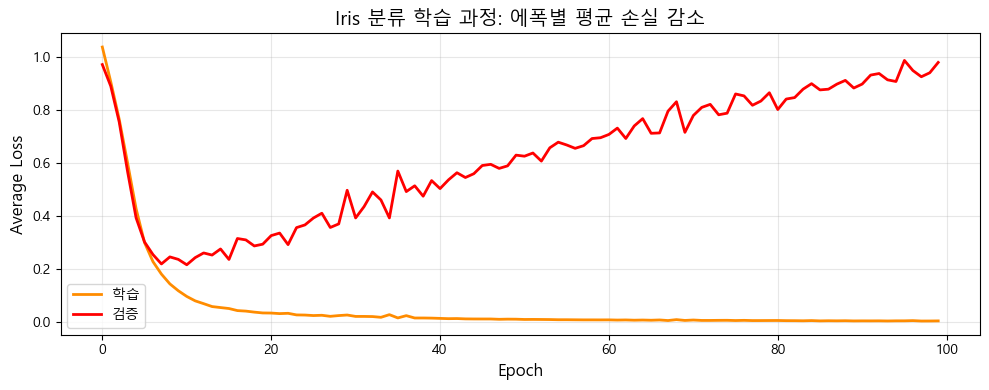

In [96]:
with torch.no_grad():
    test_output = model(x_test)
    _, predicted = torch.max(test_output, dim=1)

    correct = (predicted == y_test).sum().item()
    total = y_test.size(0)
    accuracy = correct / total*100

print(f"테스트 정확도: {accuracy:.1f}% ({correct}/{total})")

# 한글깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 손실 감소 그래프
plt.figure(figsize=(10, 4))
plt.plot(epoch_losses, color='darkorange', linewidth=2, label='학습')
plt.plot(epoch_val_losses, color='red', linewidth=2, label='검증')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.title('Iris 분류 학습 과정: 에폭별 평균 손실 감소', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

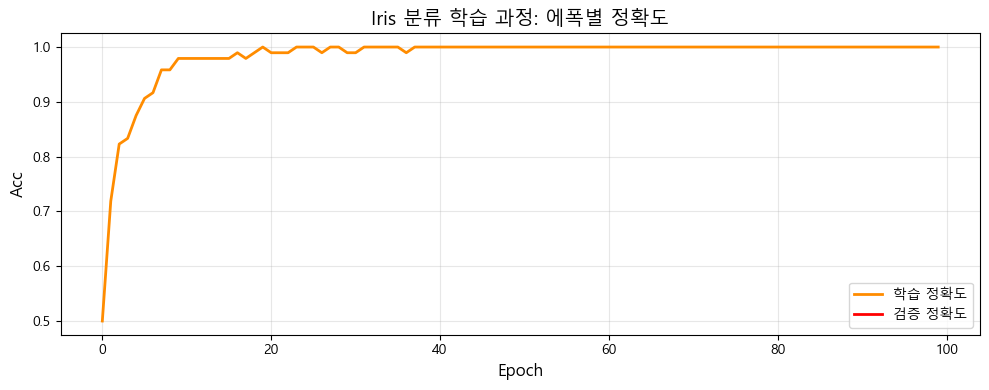

In [97]:
# 한글깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 손실 감소 그래프
plt.figure(figsize=(10, 4))
plt.plot(epoch_accs, color='darkorange', linewidth=2, label='학습 정확도')
plt.plot(val_acc, color='red', linewidth=2, label='검증 정확도')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Acc', fontsize=12)
plt.title('Iris 분류 학습 과정: 에폭별 정확도', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()